<a href="https://colab.research.google.com/github/samanta-muskan/PRODIGY_ML_01/blob/main/Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import joblib

In [2]:

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

Saving Mall_Customers.csv to Mall_Customers.csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
m

In [4]:

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


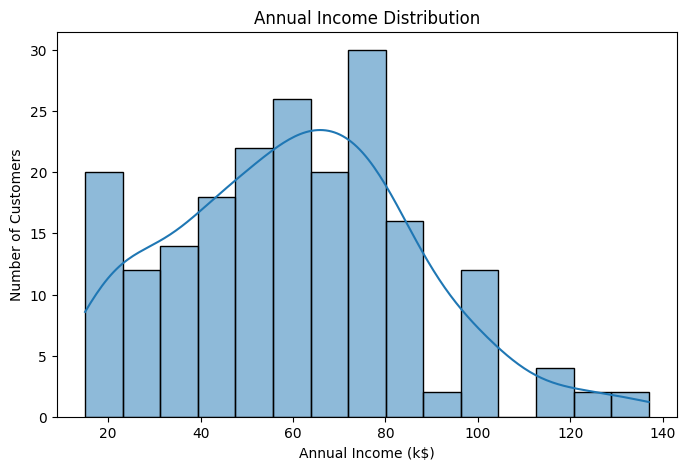

In [5]:

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Annual Income (k$)"],
    bins=15,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

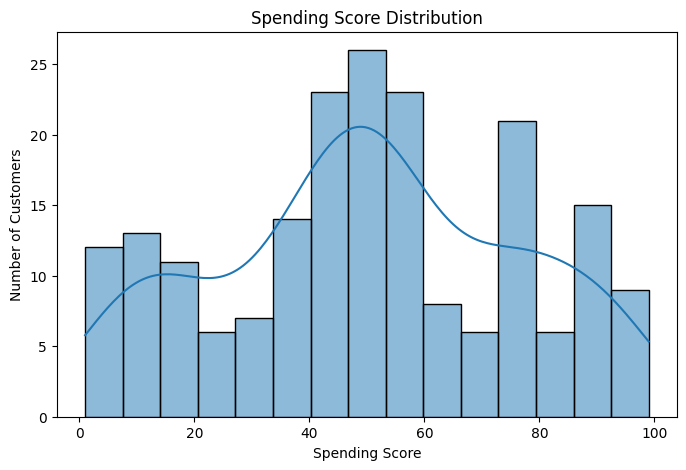

In [6]:

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Spending Score (1-100)"],
    bins=15,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

In [7]:

# Select features
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [8]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


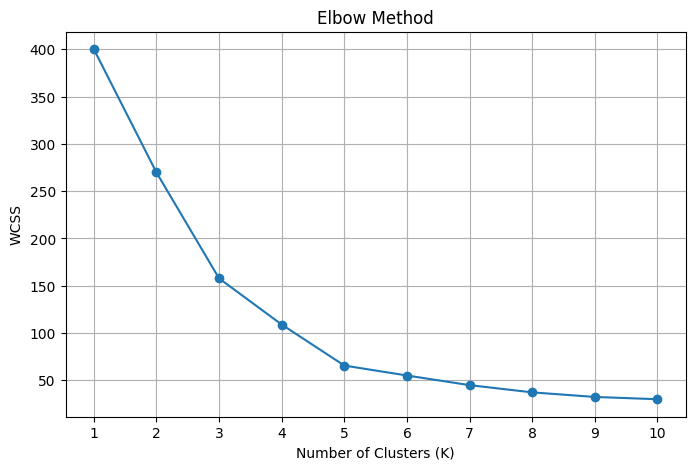

In [9]:

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [10]:

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.321
K = 3, Silhouette Score = 0.467
K = 4, Silhouette Score = 0.494
K = 5, Silhouette Score = 0.555
K = 6, Silhouette Score = 0.540
K = 7, Silhouette Score = 0.528
K = 8, Silhouette Score = 0.455
K = 9, Silhouette Score = 0.457
K = 10, Silhouette Score = 0.443


In [11]:

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

# Train the model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print(df.head())

K-Means clustering completed!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


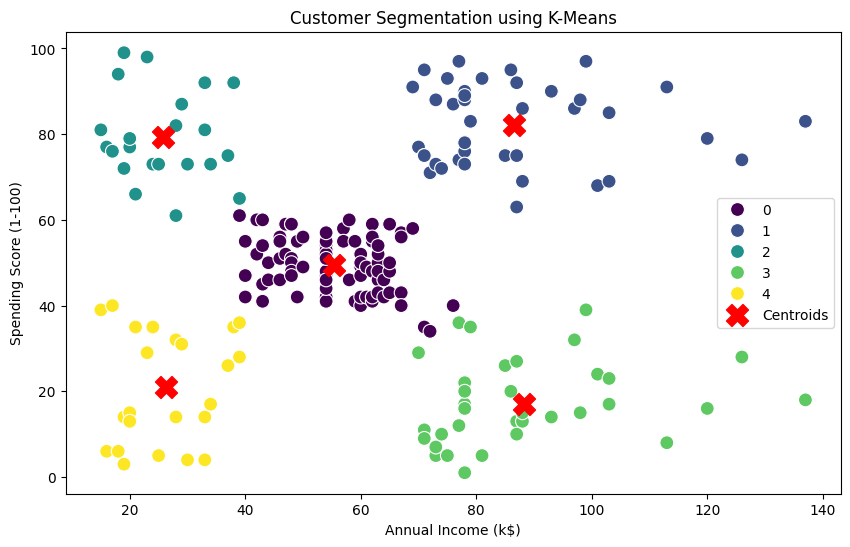

In [12]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=100
)

# Convert cluster centres back to original units
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=250,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [13]:

cluster_summary = df.groupby("Cluster").agg({
    "CustomerID": "count",
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

cluster_summary = cluster_summary.rename(
    columns={"CustomerID": "Number of Customers"}
)

print(cluster_summary)

         Number of Customers    Age  Annual Income (k$)  \
Cluster                                                   
0                         81  42.72               55.30   
1                         39  32.69               86.54   
2                         22  25.27               25.73   
3                         35  41.11               88.20   
4                         23  45.22               26.30   

         Spending Score (1-100)  
Cluster                          
0                         49.52  
1                         82.13  
2                         79.36  
3                         17.11  
4                         20.91  


In [14]:

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.555


In [15]:

# Details of a new customer
new_customer = pd.DataFrame({
    "Annual Income (k$)": [60],
    "Spending Score (1-100)": [50]
})

# Standardize using the existing scaler
new_customer_scaled = scaler.transform(new_customer)

# Predict the cluster
predicted_cluster = kmeans.predict(new_customer_scaled)

print("New Customer Details:")
print("Annual Income: $60,000")
print("Spending Score: 50")

print("\nPredicted Customer Segment:", predicted_cluster[0])

New Customer Details:
Annual Income: $60,000
Spending Score: 50

Predicted Customer Segment: 0


In [16]:

# Save customer segmentation results
df.to_csv("Customer_Segments.csv", index=False)

# Save the trained model and scaler
joblib.dump(
    {"model": kmeans, "scaler": scaler},
    "customer_segmentation_model.pkl"
)

print("Customer segments saved!")
print("Model saved!")

Customer segments saved!
Model saved!


In [17]:

from google.colab import files

files.download("Customer_Segments.csv")
files.download("customer_segmentation_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this project, a K-Means Clustering algorithm was implemented to segment retail customers based on their annual income and spending score using the Mall Customer Segmentation dataset.

The dataset was explored and preprocessed, and the features were standardized before applying K-Means. The Elbow Method was used to help determine the number of clusters. The resulting customer groups were visualized and analyzed to understand different spending behaviours.

This project demonstrates how unsupervised machine learning can help businesses identify customer segments, understand purchasing behaviour and develop targeted marketing strategies.
